In [4]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import glob
import time
import multiprocessing

# Importing functions
import Functions.wind_model_func as wind_model_func
import Functions.solar_model_func as solar_model_func
import Functions.demand as demand_func
import Functions.grid_func as grid_func
import Functions.config as config

In [1]:

import RL_function

/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [2]:
RL_function.main_observable("/climca/people/ppfleiderer/data_for_onno/step0/c1_000")

array(6274.06084804)

In [57]:
path = "/climca/people/ppfleiderer/data_for_onno/step0/c1_000/atm/hist/"
filelist = glob.glob(os.path.join(path, "*.nc"))
filelist
for file in filelist:
    if 'h1' in file:
        h1_ds = xr.open_dataset(file)
    elif 'h2' in file:
        h2_ds = xr.open_dataset(file)
        
h1_file = [f for f in filelist if "h1" in f]
h2_file = [f for f in filelist if "h2" in f]


In [59]:
h1_file

['/climca/people/ppfleiderer/data_for_onno/step0/c1_000/atm/hist/c1_000.cam.h1.2024-11-01-00000.nc']

In [58]:
h1_ds

<xarray.Dataset> Size: 22MB
Dimensions:       (lat: 192, lon: 288, lev: 32, ilev: 33, time: 5, nbnd: 2)
Coordinates:
  * lat           (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon           (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * lev           (lev) float64 256B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * ilev          (ilev) float64 264B 2.255 5.032 10.16 ... 967.5 985.1 1e+03
  * time          (time) object 40B 2024-11-01 00:00:00 ... 2024-11-05 00:00:00
Dimensions without coordinates: nbnd
Data variables: (12/45)
    gw            (lat) float64 2kB ...
    hyam          (lev) float64 256B ...
    hybm          (lev) float64 256B ...
    P0            float64 8B ...
    hyai          (ilev) float64 264B ...
    hybi          (ilev) float64 264B ...
    ...            ...
    U850          (time, lat, lon) float32 1MB ...
    V200          (time, lat, lon) float32 1MB ...
    V500          (time, lat, lon) float32 1MB ...
    V850          (time, lat, lon) float32 1MB ...
    Z200          (time, lat, lon) float32 1MB ...
    Z500          (time, lat, lon) float32 1MB ...
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              c1_000
    logname:           u290372
    host:              
    initial_file:      /work/bb1152/u290372/cesm215_input_data/atm/cam/inic/f...
    topography_file:   /work/bb1152/u290372/cesm215_input_data/atm/cam/topo/f...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1

In [15]:
h1_ds['U200']

<xarray.DataArray 'U200' (time: 5, lat: 192, lon: 288)> Size: 1MB
[276480 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * time     (time) object 40B 2024-11-01 00:00:00 ... 2024-11-05 00:00:00
Attributes:
    units:         m/s
    long_name:     Zonal wind at 200 mbar pressure surface
    cell_methods:  time: mean

In [6]:
# Importing libraries
import os,sys,glob
import xarray as xr
import numpy as np

# Importing functions
import Functions.wind_model_func as wind_model_func
import Functions.solar_model_func as solar_model_func
import Functions.demand as demand_func
import Functions.grid_func as grid_func
import Functions.config as config

def main_observable(archive_path):
    
    # Import alpha mask for rescaling wind speed
    alpha_mask = xr.open_dataset('/climca/people/onennecke/land_sea_mask/alpha_land_sea.nc')

    # Load installed capacity data
    grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
    grid_offshore = grid_offshore['wind_off_cap']
    mask_offshore = xr.where(np.isfinite(grid_offshore), 1, 0)
    grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
    grid_onshore = grid_onshore['wind_on_cap']
    mask_onshore = xr.where(np.isfinite(grid_onshore), 1, 0)
    grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto.nc')
    # grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic.nc')
    grid_solar = grid_solar['solar_cap']
    mask_solar = xr.where(np.isfinite(grid_solar), 1, 0)
    population = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')
    population = population['population']
    mask_population = xr.where(np.isfinite(population), 1, 0)
    # Overall mask
    overall_mask = mask_offshore + mask_onshore + mask_solar + mask_population
    overall_mask = xr.where(overall_mask > 0, 1, 0)
    # Load wind height data
    grid_onsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_height_weighted.nc')
    grid_offsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted.nc')

    # Load regridded population weights data
    pop_regr_CIESIN_weights = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')

    # Load fit values from vdW Paper
    demand_fit_values = xr.open_dataset('/climca/people/onennecke/population_data/demand_fit_values_week.nc')
    
    
    # archive path wäre in deinem Fall /climca/people/ppfleiderer/data_for_onno/step0/c1_000
    h_files = glob.glob(f"{archive_path}/atm/hist/*.nc")
    assert len(h_files) > 0, f"h-file missing - {archive_path}"
    # assert len(h_files) == 1, f"multiple h1-files available - {archive_path}"
    h1_file = [f for f in h_files if "h1" in f]
    h2_file = [f for f in h_files if "h2" in f]
    
    # Load climate data
    variables = ['U10', 'FSDS', 'TREFHT', 'TREFHTMX'] # List of variables

    var_dict = {'U10': 'sfcWind', 'FSDS': 'rsds', 'TREFHT': 'tas', 'TREFHTMX': 'tasmax'}
    fincl2 = ['U10', 'TREFHT', 'TREFHTMX']
    datasets = []
    with xr.open_mfdataset(h1_file, preprocess=grid_func.preprocess) as ds1, xr.open_mfdataset(h2_file, preprocess=grid_func.preprocess) as ds2:
        for var in variables:
            ds = ds1 if var in fincl2 else ds2
            data = ds[[var]]
            nc = grid_func.regrid(data, s = 47, n = 56, w = 6, e = 16)
            if var == 'sfcWind':
                nc = wind_model_func._wind_scale(nc, 100, alpha_mask['mask'], 10)
            nc = nc.rename({var: var_dict[var]})
            datasets.append(nc)
        combined_ds = xr.merge(datasets)

        combined_ds['tas'] = combined_ds['tas'] - 273.15 # Convert temperature from Kelvin to Celsius
        combined_ds['tasmax'] = combined_ds['tasmax'] - 273.15 # Convert maximum temperature from Kelvin to Celsius

        wepot_off = wind_model_func.compute_wind_energy_potential(combined_ds['sfcWind'], grid_offsh_hub_height, 
                                                                    config.a_offshore, config.height_ref, v_cutin=config.v_cutin0_off_unb, 
                                                                    v_rated=config.v_rated0_off_unb, v_cutout=config.v_cutout0_off_unb)
        wepot_on = wind_model_func.compute_wind_energy_potential(combined_ds['sfcWind'], grid_onsh_hub_height, config.a_onshore, 
                                                                    config.height_ref, v_cutin=config.v_cutin0_on_weighted, 
                                                                    v_rated=config.v_rated0_on_weighted, v_cutout=config.v_cutout0_on_weighted)

        combined_ds['wind_off_pot'] = wepot_off['wind_off_pot']
        combined_ds['wind_on_pot'] = wepot_on['wind_on_pot']

        weprod_off = wind_model_func.compute_wind_energy_production(wepot_off, grid_offshore)
        weprod_on = wind_model_func.compute_wind_energy_production(wepot_on, grid_onshore)

        combined_ds['wind_off_prod'] = weprod_off['wind_off_prod']
        combined_ds['wind_on_prod'] = weprod_on['wind_on_prod']

        sepot = solar_model_func.compute_solar_energy_potential(combined_ds['rsds'], combined_ds['tas'], combined_ds['tasmax'], 
                                                                combined_ds['sfcWind'], constants=config.pv_constants_unb, 
                                                                gamma=config.gamma_unb, ref_temp=config.temp_ref_unb)

        # combined_ds['solar_pot'] = sepot['solar_pot'] 
        combined_ds['solar_pot'] = sepot

        seprod = solar_model_func.compute_solar_energy_production(sepot, grid_solar)

        # combined_ds['solar_prod'] = seprod['solar_prod']
        combined_ds['solar_prod'] = seprod


        # Calculate weighted sum
        weighted_temp_list = []
        for y in np.unique(combined_ds['tas']["time.year"].values):
            # print(y)
            ds_weigh_temp_0 = xr.Dataset()
            ds_weigh_temp_0['temp'] = (combined_ds['tas'].sel(time=str(y)) * pop_regr_CIESIN_weights['population']).sum(dim=['lat', 'lon'])
            weighted_temp_list.append(ds_weigh_temp_0)
            
        ds_weighted_temp = xr.concat(weighted_temp_list, dim="time") 

        # Calculate demand
        demand_ds = demand_func.compute_demand(ds_weighted_temp, demand_fit_values.sel(country = 9, period = 'week'))

        timeseries_ds = demand_ds.copy()

        timeseries_ds['sfcWind'] = combined_ds['sfcWind'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['rsds']    = combined_ds['rsds'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['tas']     = combined_ds['tas'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
        timeseries_ds['tasmax']  = combined_ds['tasmax'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)

        timeseries_ds['wind_off_prod'] = combined_ds['wind_off_prod'].sum(dim=['lat', 'lon']) / 1000000
        timeseries_ds['wind_on_prod'] = combined_ds['wind_on_prod'].sum(dim=['lat', 'lon']) / 1000000
        timeseries_ds['solar_prod'] = combined_ds['solar_prod'].sum(dim=['lat', 'lon']) / 1000000

        timeseries_ds['total_prod'] = timeseries_ds['wind_off_prod'] + timeseries_ds['wind_on_prod'] + timeseries_ds['solar_prod']
        timeseries_ds['Netto'] = timeseries_ds['total_prod'] - timeseries_ds['demand']
        timeseries_ds['Residual_load'] = timeseries_ds['demand'] - timeseries_ds['total_prod']

        RL = sum(timeseries_ds['Residual_load']).values

        return RL, timeseries_ds, combined_ds, wepot_off, wepot_on, sepot

In [7]:
RL, timeseries_ds, combined_ds, wepot_off, wepot_on, sepot = main_observable("/climca/people/ppfleiderer/data_for_onno/step0/c1_000")
RL

array(6274.06084804)

In [15]:
np.mean(timeseries_ds['Residual_load']).values

array(1254.81216961)

In [17]:
timeseries_ds.load()

<xarray.Dataset> Size: 508B
Dimensions:        (time: 5)
Coordinates:
  * time           (time) object 40B 2024-11-01 00:00:00 ... 2024-11-05 00:00:00
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    country        float64 8B 9.0
    period         <U7 28B 'week'
Data variables:
    temp           (time) float64 40B 7.479 5.735 5.918 6.136 5.724
    demand         (time) float64 40B 1.426e+03 1.449e+03 ... 1.449e+03
    sfcWind        (time) float32 20B 2.742 2.254 2.527 2.382 2.923
    rsds           (time) float32 20B 92.71 97.39 93.42 92.93 87.49
    tas            (time) float32 20B 7.734 6.167 6.378 6.537 6.26
    tasmax         (time) float32 20B 11.13 10.78 11.54 11.78 10.97
    wind_off_prod  (time) float64 40B 4.651 3.249 12.22 9.697 21.53
    wind_on_prod   (time) float64 40B 18.38 13.22 20.75 19.63 35.13
    solar_prod     (time) float64 40B 152.2 164.1 160.2 157.4 146.7
    total_prod     (time) float64 40B 175.2 180.6 193.2 186.7 203.3
    Netto          (time) float64 40B -1.251e+03 -1.268e+03 ... -1.245e+03
    Residual_load  (time) float64 40B 1.251e+03 1.268e+03 ... 1.245e+03

In [5]:
def setup_gridlines(ax, deg = 1, alpha = 0.4):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

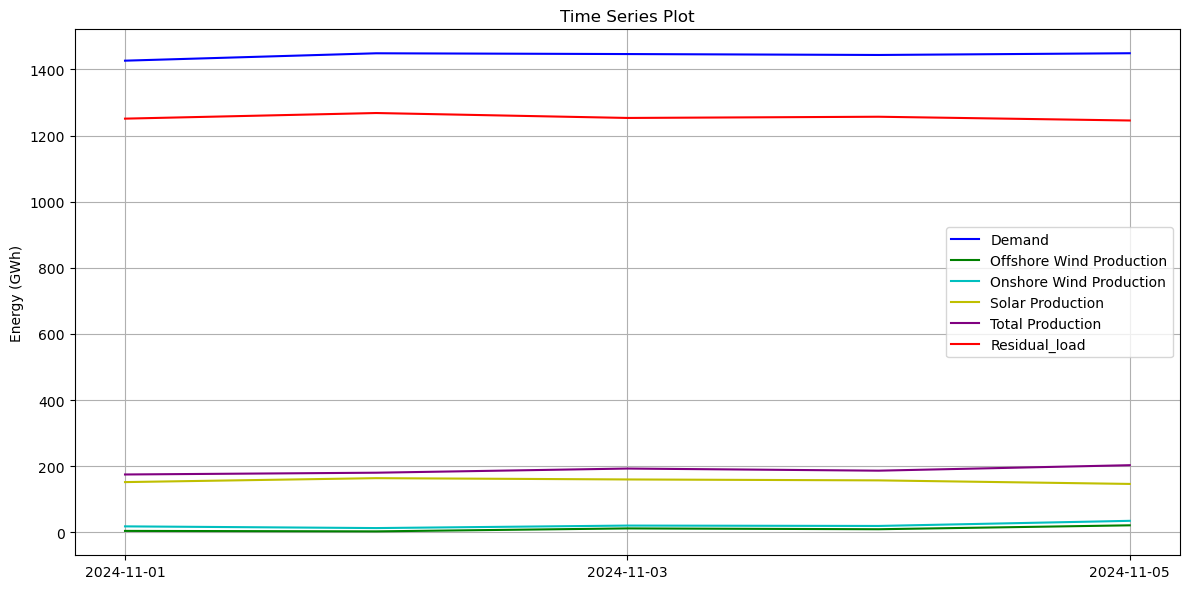

In [22]:
# Define your slice (adjust these to your desired time range)
# a = 191 + 365 * 81
# b = 7 + 365 * 82
# a = 365 * 164
# b = 365 * 165
a = 0
b = 364
# a = 365
# b = 365 * 2

# Extract time and variables for the chosen range
time = timeseries_ds['time'][:]
demand = timeseries_ds['demand'][:]
wind_off = timeseries_ds['wind_off_prod'][:]
wind_on = timeseries_ds['wind_on_prod'][:]
solar = timeseries_ds['solar_prod'][:]
total_prod = timeseries_ds['total_prod'][:]
Residual_load = timeseries_ds['Residual_load'][:]

# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each variable
ax.plot(time, demand, label='Demand', color='b')
ax.plot(time, wind_off, label='Offshore Wind Production', color='g')
ax.plot(time, wind_on, label='Onshore Wind Production', color='c')
ax.plot(time, solar, label='Solar Production', color='y')
ax.plot(time, total_prod, label='Total Production', color='purple')
ax.plot(time, Residual_load, label='Residual_load', color='r')

# Labeling
ax.set_xlabel('')
ax.set_ylabel('Energy (GWh)')
ax.set_title('Time Series Plot')
ax.legend()

# Formatting
fig.tight_layout()
plt.grid(True)
plt.show()

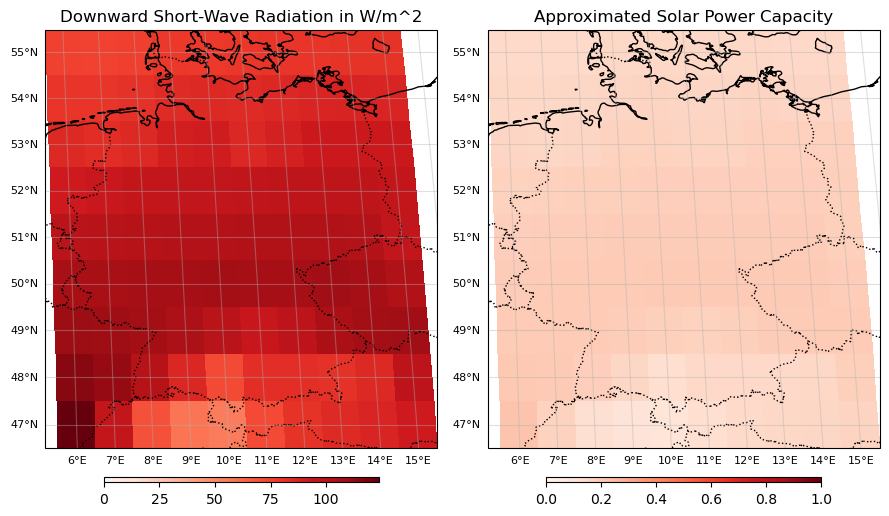

In [20]:
# Just a plot of one timestep of the solar radiation and the approximated solar power capacity
# Filter sepot so only the grids with pv data are left (mainly for plotting)
sepot_plot = sepot#.where(grid_solar > 0)

# '''
lon_edges = combined_ds['lon'].values # - (combined_ds['lon'].lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = combined_ds['lat'].values # - (combined_ds['lat'].lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

vmin = 0 
vmax = 1

# Plot the data
timestep = 0# 29937# 1# 10000 # 24507

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx1 = combined_ds['rsds'].isel(time=timestep)
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin)
setup_gridlines(ax1)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('Downward Short-Wave Radiation in W/m^2')

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx2 = sepot_plot.isel(time=timestep)
im2 = ax2.pcolormesh(lon_edges, lat_edges, xxx2, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
setup_gridlines(ax2)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('Approximated Solar Power Capacity')

plt.tight_layout()
plt.show()
# '''

In [36]:
def main_observable_tst(archive_path):
    # archive path wäre in deinem Fall /climca/people/ppfleiderer/data_for_onno/step0/c1_000
    h_files = glob.glob(f"{archive_path}/atm/hist/*.nc")
    assert len(h_files) > 0, f"h-file missing - {archive_path}"
    # assert len(h_files) == 1, f"multiple h1-files available - {archive_path}"
    h1_file = [f for f in h_files if "h1" in f]
    h2_file = [f for f in h_files if "h2" in f]
    
    # Load climate data
    variables = ['FSDS', 'TREFHT', 'TREFHTMX'] # List of variables

    var_dict = {'U10': 'sfcWind', 'FSDS': 'rsds', 'TREFHT': 'tas', 'TREFHTMX': 'tasmax'}
    fincl2 = ['U10', 'TREFHT', 'TREFHTMX']
    datasets = []
    with xr.open_mfdataset(h1_file, preprocess=grid_func.preprocess) as ds1, xr.open_mfdataset(h2_file, preprocess=grid_func.preprocess) as ds2:
        for var in variables:
            ds = ds1 if var in fincl2 else ds2
            data = ds[[var]]
            nc = grid_func.regrid(data, s = 47, n = 56, w = 6, e = 16)
            nc = nc.rename({var: var_dict[var]})
            datasets.append(nc)
        combined_ds = xr.merge(datasets)
    return combined_ds

In [37]:
combined_ds = main_observable_tst("/climca/people/ppfleiderer/data_for_onno/step0/c1_000")
combined_ds.load()


<xarray.Dataset> Size: 6kB
Dimensions:   (time: 5, lat: 9, lon: 10)
Coordinates:
  * time      (time) object 40B 2024-11-01 00:00:00 ... 2024-11-05 00:00:00
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
Data variables:
    rsds      (time, lat, lon) float32 2kB 123.6 96.47 70.18 ... 71.43 71.36
    tas       (time, lat, lon) float32 2kB 282.9 281.0 279.5 ... 283.4 283.7
    tasmax    (time, lat, lon) float32 2kB 288.1 285.6 283.5 ... 285.0 284.6
Attributes:
    regrid_method:  bilinear

In [ ]:
combined_ds['tas'] = combined_ds['tas'] - 273.15 # Convert temperature from Kelvin to Celsius
combined_ds['tasmax'] = combined_ds['tasmax'] - 273.15 # Convert maximum temperature from Kelvin to Celsius

wepot_off = wind_model_func.compute_wind_energy_potential(combined_ds['sfcWind'], grid_offsh_hub_height, 
                                                            config.a_offshore, config.height_ref, v_cutin=config.v_cutin0_off_unb, 
                                                            v_rated=config.v_rated0_off_unb, v_cutout=config.v_cutout0_off_unb)
wepot_on = wind_model_func.compute_wind_energy_potential(combined_ds['sfcWind'], grid_onsh_hub_height, config.a_onshore, 
                                                            config.height_ref, v_cutin=config.v_cutin0_on_weighted, 
                                                            v_rated=config.v_rated0_on_weighted, v_cutout=config.v_cutout0_on_weighted)

combined_ds['wind_off_pot'] = wepot_off['wind_off_pot']
combined_ds['wind_on_pot'] = wepot_on['wind_on_pot']

weprod_off = wind_model_func.compute_wind_energy_production(wepot_off, grid_offshore)
weprod_on = wind_model_func.compute_wind_energy_production(wepot_on, grid_onshore)

combined_ds['wind_off_prod'] = weprod_off['wind_off_prod']
combined_ds['wind_on_prod'] = weprod_on['wind_on_prod']

sepot = solar_model_func.compute_solar_energy_potential(combined_ds['rsds'], combined_ds['tas'], combined_ds['tasmax'], 
                                                        combined_ds['sfcWind'], constants=config.pv_constants_unb, 
                                                        gamma=config.gamma_unb, ref_temp=config.temp_ref_unb)

# combined_ds['solar_pot'] = sepot['solar_pot'] 
combined_ds['solar_pot'] = sepot

seprod = solar_model_func.compute_solar_energy_production(sepot, grid_solar)

# combined_ds['solar_prod'] = seprod['solar_prod']
combined_ds['solar_prod'] = seprod


# Calculate weighted sum
weighted_temp_list = []
for y in np.unique(combined_ds['tas']["time.year"].values):
    # print(y)
    ds_weigh_temp_0 = xr.Dataset()
    ds_weigh_temp_0['temp'] = (combined_ds['tas'].sel(time=str(y)) * pop_regr_CIESIN_weights['population']).sum(dim=['lat', 'lon'])
    weighted_temp_list.append(ds_weigh_temp_0)
    
ds_weighted_temp = xr.concat(weighted_temp_list, dim="time") 

# Calculate demand
demand_ds = demand_func.compute_demand(ds_weighted_temp, demand_fit_values.sel(country = 9, period = 'week'))

timeseries_ds = demand_ds.copy()

timeseries_ds['sfcWind'] = combined_ds['sfcWind'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
timeseries_ds['rsds']    = combined_ds['rsds'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
timeseries_ds['tas']     = combined_ds['tas'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
timeseries_ds['tasmax']  = combined_ds['tasmax'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)

timeseries_ds['wind_off_prod'] = combined_ds['wind_off_prod'].sum(dim=['lat', 'lon']) / 1000000
timeseries_ds['wind_on_prod'] = combined_ds['wind_on_prod'].sum(dim=['lat', 'lon']) / 1000000
timeseries_ds['solar_prod'] = combined_ds['solar_prod'].sum(dim=['lat', 'lon']) / 1000000

timeseries_ds['total_prod'] = timeseries_ds['wind_off_prod'] + timeseries_ds['wind_on_prod'] + timeseries_ds['solar_prod']
timeseries_ds['Netto'] = timeseries_ds['total_prod'] - timeseries_ds['demand']
timeseries_ds['Residual_load'] = timeseries_ds['demand'] - timeseries_ds['total_prod']

RL = sum(timeseries_ds['Residual_load'])

<xarray.DataArray 'Residual_load' ()> Size: 8B
array(7799.64921673)
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    country   float64 8B 9.0
    period    <U7 28B 'week'
    time      object 8B 2024-11-05 00:00:00

In [ ]:
nc = 3

In [ ]:

combined_ds['tas'] = combined_ds['tas'] - 273.15 # Convert temperature from Kelvin to Celsius
combined_ds['tasmax'] = combined_ds['tasmax'] - 273.15 # Convert maximum temperature from Kelvin to Celsius

wepot_off = wind_model_func.compute_wind_energy_potential(combined_ds['sfcWind'], grid_offsh_hub_height, 
                                                            config.a_offshore, config.height_ref, v_cutin=config.v_cutin0_off_unb, 
                                                            v_rated=config.v_rated0_off_unb, v_cutout=config.v_cutout0_off_unb)
wepot_on = wind_model_func.compute_wind_energy_potential(combined_ds['sfcWind'], grid_onsh_hub_height, config.a_onshore, 
                                                            config.height_ref, v_cutin=config.v_cutin0_on_weighted, 
                                                            v_rated=config.v_rated0_on_weighted, v_cutout=config.v_cutout0_on_weighted)

combined_ds['wind_off_pot'] = wepot_off['wind_off_pot']
combined_ds['wind_on_pot'] = wepot_on['wind_on_pot']

weprod_off = wind_model_func.compute_wind_energy_production(wepot_off, grid_offshore)
weprod_on = wind_model_func.compute_wind_energy_production(wepot_on, grid_onshore)

combined_ds['wind_off_prod'] = weprod_off['wind_off_prod']
combined_ds['wind_on_prod'] = weprod_on['wind_on_prod']

sepot = solar_model_func.compute_solar_energy_potential(combined_ds['rsds'], combined_ds['tas'], combined_ds['tasmax'], 
                                                        combined_ds['sfcWind'], constants=config.pv_constants_unb, 
                                                        gamma=config.gamma_unb, ref_temp=config.temp_ref_unb)

# combined_ds['solar_pot'] = sepot['solar_pot'] 
combined_ds['solar_pot'] = sepot

seprod = solar_model_func.compute_solar_energy_production(sepot, grid_solar)

# combined_ds['solar_prod'] = seprod['solar_prod']
combined_ds['solar_prod'] = seprod


# Calculate weighted sum
weighted_temp_list = []
for y in np.unique(combined_ds['tas']["time.year"].values):
    # print(y)
    ds_weigh_temp_0 = xr.Dataset()
    ds_weigh_temp_0['temp'] = (combined_ds['tas'].sel(time=str(y)) * pop_regr_CIESIN_weights['population']).sum(dim=['lat', 'lon'])
    weighted_temp_list.append(ds_weigh_temp_0)
    
ds_weighted_temp = xr.concat(weighted_temp_list, dim="time") 

# Calculate demand
demand_ds = demand_func.compute_demand(ds_weighted_temp, demand_fit_values.sel(country = 9, period = 'week'))

timeseries_ds = demand_ds.copy()

# timeseries_ds['sfcWind_ntmsk'] = combined_ds['sfcWind'].mean(dim=['lat', 'lon'])
# timeseries_ds['rsds_ntmsk'] = combined_ds['rsds'].mean(dim=['lat', 'lon'])
# timeseries_ds['tas_ntmsk'] = combined_ds['tas'].mean(dim=['lat', 'lon'])
# timeseries_ds['tasmax_ntmsk'] = combined_ds['tasmax'].mean(dim=['lat', 'lon'])
timeseries_ds['sfcWind'] = combined_ds['sfcWind'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
timeseries_ds['rsds']    = combined_ds['rsds'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
timeseries_ds['tas']     = combined_ds['tas'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
timeseries_ds['tasmax']  = combined_ds['tasmax'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)

timeseries_ds['wind_off_prod'] = combined_ds['wind_off_prod'].sum(dim=['lat', 'lon']) / 1000000
timeseries_ds['wind_on_prod'] = combined_ds['wind_on_prod'].sum(dim=['lat', 'lon']) / 1000000
timeseries_ds['solar_prod'] = combined_ds['solar_prod'].sum(dim=['lat', 'lon']) / 1000000

timeseries_ds['total_prod'] = timeseries_ds['wind_off_prod'] + timeseries_ds['wind_on_prod'] + timeseries_ds['solar_prod']
timeseries_ds['Netto'] = timeseries_ds['total_prod'] - timeseries_ds['demand']
timeseries_ds['Residual_load'] = timeseries_ds['demand'] - timeseries_ds['total_prod']

RL = sum(timeseries_ds['Residual_load'])


print('Run time: ', int(np.floor((time.time()  - run_time) / 60)),'m', round((time.time()  - run_time) % 60,1),'s')
    # break
    

In [ ]:
# Load climate data
variables = ['U10', 'FSDS', 'TREFHT', 'TREFHTMX'] # List of variables
var_dict = {'U10': 'sfcWind', 'FSDS': 'rsds', 'TREFHT': 'tas', 'TREFHTMX': 'tasmax'}


# for i in range(len(df[0:2])):
# def one_run(i):
ESM = 'CESM2_LE'
run_time = time.time()

# Create list to save datasets for each variable
datasets = []

for var in variables:
        
    print(f'Processing variable: {var}')
    # if var == 'TREFHT':
    #     path = f'/climca/data/CESM2_LE/TREFHT_new/day_raw/b.e21.{experiment}.f09_g17.{LE_ID_frcng}.{ensemble_member}.cam.h1.{var}.20150101-20241231.nc'
    # else:
    #     path = f'/climca/data/CESM2_LE/{var}/day_raw/b.e21.{experiment}.f09_g17.{LE_ID_frcng}.{ensemble_member}.cam.h1.{var}.20150101-20241231.nc'
        
    
    path = 'xx' ################## Read new data
    
    files = [f for f in glob.glob(path) if f.endswith('.nc')]

    nc = xr.open_mfdataset(files, preprocess=grid_func.preprocess)
    nc = nc[[var]]
    # Filter Time??????????
    nc = grid_func.regrid(nc, s = 47, n = 56, w = 6, e = 16)  # Regrid the data
    
    nc = nc.drop_vars('height') if 'height' in nc.coords else nc
    
    nc = nc.rename({var: var_dict[var]})
    
    if var == 'sfcWind':
        nc = wind_model_func._wind_scale(nc, 100, alpha_mask['mask'], 10)
    
    
    nc = nc.load()
    
    datasets.append(nc)
    
    # Save the dataset
    # nc.to_netcdf(output_file)

    print('Run time: ', int(np.floor((time.time()  - run_time) / 60)),'m', round((time.time()  - run_time) % 60,1),'s', '\n')

# Combine all variables into one dataset
combined_ds = xr.merge(datasets)

